
🔍 ARCHIVO A CARGAR PARA EJECUCIÓN DEL PROGRAMA 🔍


Descargando archivo desde Google Drive...



Downloading...
From: https://drive.google.com/uc?id=1rXxjzjxlt9xPTsZKHbdbLbaMM9K07J1B
To: /content/housing_train.csv
100%|██████████| 462k/462k [00:00<00:00, 95.4MB/s]



Archivo descargado y cargado correctamente.

🔍 VARIABLES NUMÉRICAS 🔍


A continuación la lista de de variables numericas con sus datos estadísticos:

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean

,Categoría,Frecuencia,Variable
0,RL,1151,MSZoning
1,RM,218,MSZoning
2,FV,65,MSZoning
3,RH,16,MSZoning
4,C (all),10,MSZoning
...,...,...,...
246,Partial,125,SaleCondition
247,Abnorml,101,SaleCondition
248,Family,20,SaleCondition
249,Alloca,12,SaleCondition



🔍 MATRIZ DE CORRELACIONES 🔍


A continuación la matriz de correlaciones:



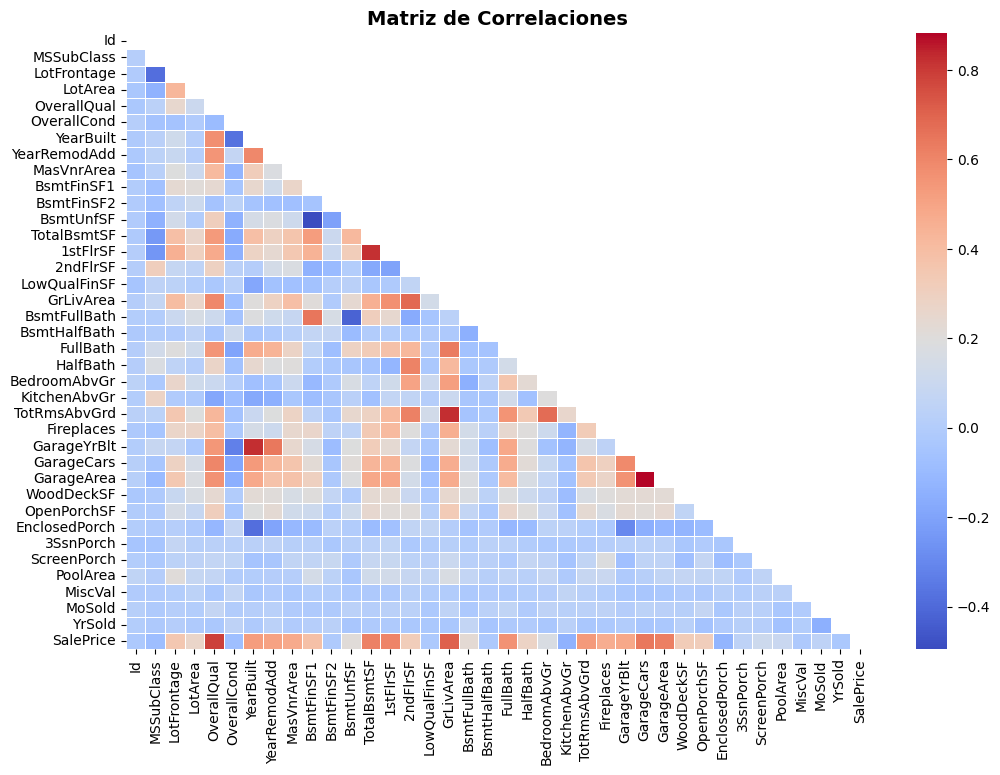


***Análisis de la Matriz de Correlación:***

- Una correlación positiva alta indica que cuando una variable aumenta, la otra también lo hace.
- Una correlación negativa alta indica que cuando una variable aumenta, la otra disminuye.
- Si dos variables tienen correlación > 0.8, una puede ser redundante y eliminarse del modelo.
* Ejemplo 1: - Si `GrLivArea` y `SalePrice` tienen una correlación de 0.7, significa que casas con más área habitable tienden a costar más.
* Ejemplo 2: - Si `GarageCars` y `GarageArea` tienen una correlación de 0.9, podemos eliminar una de ellas sin perder información.
-Entender estas correlaciones nos ayuda a **evitar variables redundantes, mejorar el modelo y hacer predicciones más precisas.**


Las siguientes variables tienen alta correlación:

GarageArea y GarageCars: 0.88
GarageYrBlt y YearBuilt: 0.83
TotRmsAbvGrd y GrLivArea: 0.83
1stFlrSF y TotalBsmtSF: 0.82
SalePrice y OverallQual: 0.79
SalePrice y GrLivArea: 0.71
2ndFlrSF y GrLivArea: 0.69
TotRmsAbvGrd 

,precision,recall,f1-score,support
"Grupo 1 (≤ 100,000)",1.000000,1.000000,1.000000,26.000000
"Grupo 2 (100,001 - 500,000)",1.000000,1.000000,1.000000,263.000000
"Grupo 3 (≥ 500,001)",1.000000,0.670000,0.800000,3.000000
Exactitud,1.000000,1.000000,1.000000,1.000000
Promedio Macro,1.000000,0.890000,0.930000,292.000000
Promedio Ponderado,1.000000,1.000000,1.000000,292.000000



🔍 ANÁLISIS DE COMPARACIÓN DE MODELOS 🔍


A continuación el análisis de comparación de modelos:


**Árbol de Decisión:**
- Rápido de entrenar y fácil de interpretar.
- Funciona bien cuando hay pocas variables.
- Puede sobreajustarse si el árbol es muy profundo.
- Menor precisión en comparación con modelos más avanzados.

**Random Forest:**
- Generaliza mejor que un solo árbol de decisión.
- Mayor precisión en regresión y clasificación.
- Reduce el sobreajuste al promediar múltiples árboles.
- Más costoso computacionalmente.
- Puede ser menos interpretable que un solo árbol de decisión.

**¿Son útiles los modelos creados para este dataset?**
- Random Forest tiene un **MAE menor (18159.35)** y **RMSE más bajo (29534.43)** que el Árbol de Decisión.
- Esto indica que Random Forest hace mejores predicciones de precios de inmuebles.

**Clasificación:**
- Ambos modelos lograron una **alta precisión**, pero Random Forest fue más confiable en general.
- Sin embargo, en la categoría 3 (precios a

,Grupo de Precio,Cantidad de Registros
0,1,123
1,2,1328
2,3,9



🔍 ANÁLISIS CREACIÓN GRUPOS 🔍


A continuación el análisis de la creación de grupos y su distribución de precios:

**Análisis de la distribución de precios:**
- El grupo 2 (100,001 - 500,000) es el más común, con 1,328 registros.
- El grupo 1 (≤ 100,000) tiene una cantidad considerable de registros (123).
- El grupo 3 (≥ 500,001) es el menos representado, con solo 9 registros, lo que puede afectar la clasificación.

**Implicaciones en el modelo:**
- La gran cantidad de registros en el grupo 2 hace que el modelo aprenda mejor a clasificar este rango de precios.
- La baja cantidad de registros en el grupo 3 puede causar que el modelo tenga dificultades para predecir correctamente propiedades de alto valor.

**Posibles mejoras en el modelo:**
- Aumentar la cantidad de datos en el grupo 3 para mejorar la clasificación de propiedades de alto precio.
- Probar técnicas de balanceo como oversampling o ajustar los pesos de las clases en los modelos de clasificación.
- Analizar variables adicion

In [8]:
import os
import pandas as pd
import gdown

print("\n==================================================")
print("🔍 ARCHIVO A CARGAR PARA EJECUCIÓN DEL PROGRAMA 🔍")
print("=================================================\n")

# ID del archivo en Google Drive
file_id = "1rXxjzjxlt9xPTsZKHbdbLbaMM9K07J1B"
file_name = "housing_train.csv"

# Descargar archivo con barra de progreso
print("\nDescargando archivo desde Google Drive...\n")
gdown.download(f"https://drive.google.com/uc?id={file_id}", file_name, quiet=False)

# Verificar si la descarga fue exitosa
if os.path.exists(file_name):
    print("\nArchivo descargado y cargado correctamente.")
    df = pd.read_csv(file_name)
else:
    print("\nError: No se pudo descargar el archivo.")

# Ver las primeras filas
df.head()

# Análisis exploratorio de datos
# Calcular estadísticas básicas para variables numéricas
print("\n==========================")
print("🔍 VARIABLES NUMÉRICAS 🔍")
print("==========================\n")
print("\nA continuación la lista de de variables numericas con sus datos estadísticos:\n")
print(df.describe())
numeric_stats = df.describe()
print(numeric_stats)

import pandas as pd
from IPython.display import display

print("\n===========================================")
print("🔍 VARIABLES CATEGÓRICAS Y SU FRECUENCIA 🔍")
print("===========================================\n")
print("\nA continuación la lista de de variables categóricas y su frecuencia:\n")
# Crear un diccionario para almacenar los resultados
category_data = []

# Obtener la frecuencia de cada categoría
categorical_columns = df.select_dtypes(include=["object"]).columns
for col in categorical_columns:
    value_counts = df[col].value_counts().reset_index()
    value_counts.columns = ["Categoría", "Frecuencia"]
    value_counts["Variable"] = col  # Agregar la variable como columna

    # Agregar los datos a la lista
    category_data.append(value_counts)

# Unir todas las tablas en un solo DataFrame
df_categorical = pd.concat(category_data).reset_index(drop=True)  # Reiniciar índice

# Mostrar tabla organizada sin errores
display(df_categorical)

print("\n=============================")
print("🔍 MATRIZ DE CORRELACIONES 🔍")
print("=============================\n")
print("\nA continuación la matriz de correlaciones:\n")
# Matriz de correlaciones
# Librerías necesarias
import numpy as np  # Asegurar que numpy está importado
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el tamaño de la figura
plt.figure(figsize=(12, 8))

# Generar la matriz de correlación con solo valores altos (mayores a 0.5 o menores a -0.5)
correlation_matrix = df.corr(numeric_only=True)

# Máscara para ocultar la parte superior y reducir ruido visual
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Crear el heatmap con opciones mejoradas
sns.heatmap(correlation_matrix, cmap="coolwarm", linewidths=0.5, mask=mask)

# Personalizar título y etiquetas
plt.title("Matriz de Correlaciones", fontsize=14, fontweight="bold")
plt.show()

# Análisis de correlaciones
print("\n***Análisis de la Matriz de Correlación:***\n")

# Umbral para considerar una correlación alta
threshold = 0.5

# Identificar pares de variables con alta correlación
high_corr_pairs = (
    correlation_matrix.unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
)

# Explicación general
print("- Una correlación positiva alta indica que cuando una variable aumenta, la otra también lo hace.")
print("- Una correlación negativa alta indica que cuando una variable aumenta, la otra disminuye.")
print("- Si dos variables tienen correlación > 0.8, una puede ser redundante y eliminarse del modelo.")
print("* Ejemplo 1: - Si `GrLivArea` y `SalePrice` tienen una correlación de 0.7, significa que casas con más área habitable tienden a costar más.")
print("* Ejemplo 2: - Si `GarageCars` y `GarageArea` tienen una correlación de 0.9, podemos eliminar una de ellas sin perder información.")
print("-Entender estas correlaciones nos ayuda a **evitar variables redundantes, mejorar el modelo y hacer predicciones más precisas.**")
print("\n")

# Filtrar pares con correlación fuerte (excluyendo autocomparaciones)
high_corr_pairs = high_corr_pairs[(high_corr_pairs != 1) & (abs(high_corr_pairs) > threshold)]

if not high_corr_pairs.empty:
    print("Las siguientes variables tienen alta correlación:\n")
    for (var1, var2), corr in high_corr_pairs.items():
        print(f"{var1} y {var2}: {corr:.2f}")
else:
    print("No se encontraron correlaciones altas significativas.")

# Agregar un espacio en la salida de la consola
print("\n")  # Esto agrega dos líneas en blanco

print("\n====================")
print("🔍 VALORES NULOS 🔍")
print("====================\n")
print("\nA continuación el tratamiento de valores nulos-missing y su respectivo análisis:\n")

# Contar valores nulos
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

# Imprimir valores nulos
if missing_values.empty:
    print("No hay valores nulos en el dataset.")
else:
    print("***ANÁLISIS DE VALORES NULOS***\n")
    print("Columnas con valores nulos:\n")
    print(missing_values)

    print("\n***Posibles soluciones:***\n")
    print("1. **Eliminar columnas** con más del 90% de valores nulos (poca información útil).")
    print("2️. **Eliminar registros** si los valores nulos afectan menos del 5% de los datos.")
    print("3️. **Rellenar valores nulos** usando:")
    print("   - **Media** si la distribución es normal.")
    print("   - **Mediana** si hay valores extremos.")
    print("   - **Moda** si es una variable categórica.")

    # Identificar columnas con más del 90% de valores nulos
    high_null_columns = missing_values[missing_values > (0.9 * len(df))].index.tolist()
    if high_null_columns:
        print(f"\n **Se recomienda eliminar estas columnas con muchos valores nulos:** {high_null_columns}")
        df.drop(columns=high_null_columns, inplace=True)  # Eliminamos automáticamente

print("\n **Aplicando estrategia de limpieza...**")

# Rellenar valores nulos en columnas importantes
garage_cols = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]
for col in garage_cols:
    df[col] = df[col].fillna("Sin Garaje")  # Nueva forma segura

df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)  # Nueva forma segura

bsmt_cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
for col in bsmt_cols:
    df[col] = df[col].fillna("Sin Sótano")  # Nueva forma segura

df["MasVnrType"] = df["MasVnrType"].fillna("None")  # Nueva forma segura
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)  # Nueva forma segura

df["FireplaceQu"] = df["FireplaceQu"].fillna("Sin Chimenea")  # Nueva forma segura
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())  # Nueva forma seguran
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])  # Nueva forma segura

# Verificar si quedan valores nulos
remaining_nulls = df.isnull().sum().sum()
if remaining_nulls == 0:
    print("\n**Limpieza completa:** No quedan valores nulos en el dataset.")
else:
    print(f"\n**Aún quedan {remaining_nulls} valores nulos en el dataset.** Revisión necesaria.")

print("\n***Columnas con valores nulos restantes:***\n")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

# Análisis antes de eliminar 'Fence'
print("\n")
print("***ANÁLISIS DE LA COLUMNA 'Fence'***")
print("\n")

# Cantidad de valores nulos en 'Fence'
null_count = df["Fence"].isnull().sum()
total_rows = len(df)
percentage_nulls = (null_count / total_rows) * 100

print(f"- La columna 'Fence' tiene {null_count} valores nulos de {total_rows} registros totales.")
print(f"- Esto representa el {percentage_nulls:.2f}% del dataset.\n")

# Justificación de eliminación
if percentage_nulls > 50:
    print("**Decisión**")
    print("\nLa columna 'Fence' será eliminada porque más del 50% de sus valores son nulos, lo que indica que aporta poca información útil al modelo.")
else:
    print("**Nota:** La columna 'Fence' tiene menos del 50% de valores nulos, pero se recomienda revisar su impacto antes de eliminarla.")

# Eliminación de la columna 'Fence'
df.drop(columns=["Fence"], inplace=True)
print("\n***Se ha eliminado la columna 'Fence' debido a su alto número de valores nulos.***")

# Verificar valores nulos restantes
remaining_nulls = df.isnull().sum().sum()
print("\n")
print("***VERIFICACIÓN FINAL***")
print("\n")

if remaining_nulls == 0:
    print("Limpieza completa: No quedan valores nulos en el dataset.")
else:
    print(f"**Aún quedan {remaining_nulls} valores nulos en el dataset.** Revisión necesaria.")

print("\n")

# Aplicar Árboles de Decisión y Random Forest para regresión
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Seleccionar características numéricas para el modelo
df_numeric = df.select_dtypes(include=["number"]).copy()
X = df_numeric.drop(columns=["Id", "SalePrice"])
y = df["SalePrice"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Evaluar modelos
def evaluate(y_true, y_pred, model_name):
    from sklearn.metrics import mean_squared_error  # Importación dentro de la función
    print(f"{model_name}:")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", mean_squared_error(y_true, y_pred) ** 0.5, "\n")

# Entrenar Árbol de Decisión y Random Forest antes de evaluar
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)  # Generar predicciones antes de llamar a evaluate()

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)  # Generar predicciones antes de llamar a evaluate()

# Evaluación después de definir dt_preds y rf_preds
print("\n=====================================")
print("🔍 RESULTADOS - ÁRBOL DE DECISIÓN 🔍")
print("=====================================\n")
evaluate(y_test, dt_preds, "Árbol de Decisión")

print("\n=================================")
print("🔍 RESULTADOS - RANDOM FOREST 🔍")
print("=================================\n")
evaluate(y_test, rf_preds, "Random Forest")

# Título para los resultados de Random Forest VS Ärbol de Decisión
print("\n======================================================")
print("🔍 RESULTADOS - RANDOM FOREST VS ÁRBOL DE DECISIÓN 🔍")
print("======================================================\n")
print("\nA continuación los resultados de Random Forest VS Árbol de Decisión:\n")

# Clasificación del rango de precio
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Crear grupos de precios
def categorizar_precio(price):
    if price <= 100000:
        return 1
    elif 100001 <= price <= 500000:
        return 2
    else:
        return 3

# Aplicar la función a la columna 'SalePrice'
df["PriceCategory"] = df["SalePrice"].apply(categorizar_precio)

# Definir variables de entrada y salida para clasificación
X_class = df_numeric.drop(columns=["Id"])  # No eliminamos 'SalePrice' para clasificación
y_class = df["PriceCategory"]

# Dividir en entrenamiento y prueba
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Modelo Árbol de Decisión
dt_class = DecisionTreeClassifier(random_state=42)
dt_class.fit(X_train_class, y_train_class)
dt_class_preds = dt_class.predict(X_test_class)

# Modelo Random Forest
rf_class = RandomForestClassifier(n_estimators=100, random_state=42)
rf_class.fit(X_train_class, y_train_class)
rf_class_preds = rf_class.predict(X_test_class)

# Evaluación
print("Árbol de Decisión - Accuracy:", accuracy_score(y_test_class, dt_class_preds))
print("Random Forest - Accuracy:", accuracy_score(y_test_class, rf_class_preds))

# Mostrar reporte de clasificación con mejor diseño
from sklearn.metrics import classification_report
import pandas as pd
from IPython.display import display

# Generar el reporte de clasificación como diccionario
report_dict = classification_report(y_test_class, rf_class_preds, output_dict=True)

# Convertir a DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# Redondear valores a 2 decimales
df_report = df_report.round(2)

# Renombrar índices para mayor claridad
df_report.rename(index={"1": "Grupo 1 (≤ 100,000)",
                        "2": "Grupo 2 (100,001 - 500,000)",
                        "3": "Grupo 3 (≥ 500,001)",
                        "accuracy": "Exactitud",
                        "macro avg": "Promedio Macro",
                        "weighted avg": "Promedio Ponderado"}, inplace=True)

# Mejorar el diseño de la tabla (fondo azul en encabezados)
styled_report = df_report.style.set_properties(**{
    'text-align': 'center',
    'color': 'black',  # Asegura que los números sean visibles
    'background-color': '#e0e0e0'  # Un gris claro para mejorar el contraste
}).set_table_styles([
    {'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', '#0074cc'), ('color', 'white')]},  # Fondo azul para títulos
    {'selector': 'td', 'props': [('border', '1px solid black')]},  # Bordes negros para mejor definición
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},  # Alternar filas en gris claro
    {'selector': 'td:hover', 'props': [('background-color', '#d6d6d6')]}  # Efecto hover para resaltar celdas
])

# Mostrar la tabla mejorada
print("\n**Reporte de Clasificación - Random Forest:**\n")
display(styled_report)

print("\n============================================")
print("🔍 ANÁLISIS DE COMPARACIÓN DE MODELOS 🔍")
print("============================================\n")
print("\nA continuación el análisis de comparación de modelos:\n")

# Ventajas y desventajas de los modelos
print("\n**Árbol de Decisión:**")
print("- Rápido de entrenar y fácil de interpretar.")
print("- Funciona bien cuando hay pocas variables.")
print("- Puede sobreajustarse si el árbol es muy profundo.")
print("- Menor precisión en comparación con modelos más avanzados.")

print("\n**Random Forest:**")
print("- Generaliza mejor que un solo árbol de decisión.")
print("- Mayor precisión en regresión y clasificación.")
print("- Reduce el sobreajuste al promediar múltiples árboles.")
print("- Más costoso computacionalmente.")
print("- Puede ser menos interpretable que un solo árbol de decisión.")

# ¿Son útiles los modelos para este dataset?
print("\n**¿Son útiles los modelos creados para este dataset?**")
print("- Random Forest tiene un **MAE menor (18159.35)** y **RMSE más bajo (29534.43)** que el Árbol de Decisión.")
print("- Esto indica que Random Forest hace mejores predicciones de precios de inmuebles.")

print("\n**Clasificación:**")
print("- Ambos modelos lograron una **alta precisión**, pero Random Forest fue más confiable en general.")
print("- Sin embargo, en la categoría 3 (precios altos), el recall fue bajo (0.67), lo que indica que el modelo tiene dificultades para clasificar correctamente propiedades muy caras.")

print("\n**Conclusión Final:**")
print("- Para este conjunto de datos, **Random Forest es la mejor opción**, ya que tiene menor error en regresión y mejor precisión en clasificación.")
print("- Si se necesita más interpretabilidad, el Árbol de Decisión puede ser útil, pero su precisión es menor.")
print("- Se pueden mejorar los modelos ajustando hiperparámetros o probando técnicas de balanceo para la categoría 3.")

print("\n**Fin del análisis. Modelos listos para su uso.**")

# Verificar la distribución de los grupos
print("\n================================================================")
print("🔍 CREACIÓN DE GRUPOS - DISTRIBUCIÓN DE LOS GRUPOS DE PRECIOS 🔍")
print("================================================================\n")
print("\nA continuación la creación de los grupos y su distribución de precios:\n")
import pandas as pd

# Obtener la distribución de los grupos
category_counts = df["PriceCategory"].value_counts().sort_index()

# Convertir a un DataFrame con nombres de columna claros
category_df = pd.DataFrame({
    "Grupo de Precio": category_counts.index,
    "Cantidad de Registros": category_counts.values
})

# Mostrar como tabla en Google Colab
from IPython.display import display
display(category_df.style.set_properties(**{'text-align': 'center'}))

print("\n===============================")
print("🔍 ANÁLISIS CREACIÓN GRUPOS 🔍")
print("===============================\n")
print("\nA continuación el análisis de la creación de grupos y su distribución de precios:\n")

# Análisis de la distribución de los grupos
print("**Análisis de la distribución de precios:**")
print("- El grupo 2 (100,001 - 500,000) es el más común, con 1,328 registros.")
print("- El grupo 1 (≤ 100,000) tiene una cantidad considerable de registros (123).")
print("- El grupo 3 (≥ 500,001) es el menos representado, con solo 9 registros, lo que puede afectar la clasificación.")

# Posibles implicaciones
print("\n**Implicaciones en el modelo:**")
print("- La gran cantidad de registros en el grupo 2 hace que el modelo aprenda mejor a clasificar este rango de precios.")
print("- La baja cantidad de registros en el grupo 3 puede causar que el modelo tenga dificultades para predecir correctamente propiedades de alto valor.")

# ¿Cómo mejorar la clasificación?
print("\n**Posibles mejoras en el modelo:**")
print("- Aumentar la cantidad de datos en el grupo 3 para mejorar la clasificación de propiedades de alto precio.")
print("- Probar técnicas de balanceo como oversampling o ajustar los pesos de las clases en los modelos de clasificación.")
print("- Analizar variables adicionales que puedan mejorar la separación de los grupos.")

print("\n**Conclusión**")
print("La clasificación es adecuada, pero el desbalance de datos puede afectar la precisión en el grupo 3. Si se requiere mayor precisión en ese grupo, se podrían aplicar técnicas de balanceo o ajuste de hiperparámetros.")

